In [1]:
# os.chdir("hmr4d/")
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '3,'
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
from einops import einsum
import cv2
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
import torch
from smplx.joint_names import JOINT_NAMES, SMPLH_JOINT_NAMES

from hydra import compose, initialize_config_module
from hydra.utils import instantiate

from hmr4d.configs import register_store_gvhmr
from hmr4d.network.gvhmr.relative_transformer import NetworkEncoderRoPEwithCA
from hmr4d.model.gvhmr.utils.endecoder import EnDecoder
from hmr4d.model.gvhmr.pipeline.gvhmr_pipeline import get_smpl_params_w_Rt_v2
from hmr4d.model.gvhmr.utils.postprocess import (
    pp_static_joint,
    process_ik,
    pp_static_joint_cam,
)

from hmr4d.utils.preproc import Tracker, Extractor, VitPoseExtractor, SimpleVO
from hmr4d.utils.preproc.vitpose_pytorch.src.vitpose_infer.pose_utils.pose_viz import joints_dict
from hmr4d.utils.geo.hmr_cam import get_bbx_xys_from_xyxy, estimate_K, create_camera_sensor
from hmr4d.utils.geo.hmr_cam import compute_bbox_info_bedlam, compute_transl_full_cam, normalize_kp2d
from hmr4d.utils.geo_transform import compute_cam_angvel, move_to_start_point_face_z
from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX
from hmr4d.utils.body_model.smplx_lite import SmplxLiteV437Coco17
from hmr4d.utils.video_io_utils import get_writer
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.vis.cv2_utils import draw_bbx_xyxy_on_image_batch, draw_kpts_with_conf_batch, draw_kpts_batch
from hmr4d.utils.vis.plot_vis import plot_angle_changes


/home/guangyu/patrick/GVHMR/hmr4d/network/base_arch/embeddings/rotary_embedding_v2.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/pipeline/gvhmr_pipeline.py:321: FutureWarning: `t

In [2]:
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).cuda()
smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
).cuda()
smplx_coco = SmplxLiteV437Coco17().cuda()
smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").cuda()
faces_smpl = smpl.faces
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").cuda()

/tmp/ipykernel_1100079/465735466.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").cuda()
/tmp/ipyk

In [3]:
with initialize_config_module(version_base='1.3', config_module='hmr4d.configs'):
    register_store_gvhmr()
    cfg = compose(config_name='train', overrides=[
        # 'exp=gvhmr/test/test_dinov3', 
        'exp=gvhmr/test/test_hmr'
    ])

cfg.model._target_ = 'hmr4d.model.gvhmr.gvhmr_pl_demo.DemoPL'
del cfg.model.optimizer
del cfg.model.scheduler_cfg

model = instantiate(cfg.model, _recursive_=False).eval().to('cuda')
# model.load_pretrained_model("training_results/mocap_mixed_v2_ca_dinov3/crossattn_v4/checkpoints/e099-s037700.ckpt")
model.load_pretrained_model("inputs/checkpoints/gvhmr/gvhmr_siga24_release.ckpt")

print('denoiser =', type(model.pipeline.denoiser3d).__name__)
# print('dinov3_pool =', model.pipeline.dinov3_pool)

[02/16 15:17:39][INFO] [EnDecoder] Use MM_V1_AMASS_LOCAL_BEDLAM_CAM for statistics!
[02/16 15:17:40][INFO] [PL-Trainer] Loading ckpt type: inputs/checkpoints/gvhmr/gvhmr_siga24_release.ckpt
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/gvhmr_pl_demo.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you 

denoiser = NetworkEncoderRoPEwithCA


In [4]:
tracker = Tracker()
vitpose_extractor = VitPoseExtractor()
extractor_hmr = Extractor('hmr2')
# extractor_dino = Extractor('dinov3')

/home/guangyu/anaconda3/envs/hmr/lib/python3.10/site-packages/ultralytics/nn/tasks.py:775: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location

In [5]:
# demo.py -> L41~55
# final_results = torch.load("outputs/unused/walktest/1335_T4.pt")
# video_path = Path("samples/unused/gait_related/walktest/1335_T4.mp4")
# output_root = Path("outputs/unused/walktest")
video_path = Path("samples/debug/emdb_debug/P1_14_outdoor_climb-870-990.mp4")
output_root = Path("outputs/debug/emdb_debug")
output_root.mkdir(parents=True, exist_ok=True)
static_cam = False
use_dpvo = False
f_mm = None

# demo.py -> L60
# hmr4d.utils.video_io_utils.get_video_lwh
length, height, width, c = iio.improps(video_path, plugin="pyav").shape
if length == 0:
    video = cv2.VideoCapture(str(video_path))
    fps = video.get(cv2.CAP_PROP_FPS)
    length = int(video.get(cv2.CAP_PROP_FRAME_COUNT))-1
print(f"{str(video_path)}: {width}x{height}x{length}")

samples/debug/emdb_debug/P1_14_outdoor_climb-870-990.mp4: 1440x1920x120


In [6]:
track_history = tracker.track(video_path)
vid_length = len(track_history)
id_to_frame_ids, id_to_bbx_xyxys, id_sorted = tracker.sort_track_length(track_history, video_path)

for k in id_sorted:
    lst = id_to_frame_ids[k]
    ranges = np.split(lst, np.where(np.diff(lst)!=1)[0]+1)
    ranges = [(x[0], x[-1]) if len(x) > 1 else (x[0], x[0]) for x in ranges]
    print(f"track id {k}: {len(lst)} frames, ranges: {ranges}")

YoloV8 Tracking: 100%|██████████| 120/120 [00:10<00:00, 11.53it/s]

track id 1: 120 frames, ranges: [(0, 119)]
track id 3: 30 frames, ranges: [(38, 39), (41, 53), (55, 69)]
track id 4: 22 frames, ranges: [(46, 67)]
track id 5: 22 frames, ranges: [(86, 92), (96, 98), (100, 100), (103, 104), (106, 114)]


In [7]:
track_ids = [1]
frame_ids, bbx_xyxys = [], []
for track_id in track_ids:
    tmp_id = torch.tensor(id_to_frame_ids[track_id])  # (N,)
    frame_ids.append(tmp_id)
    tmp_xyxy = torch.tensor(id_to_bbx_xyxys[track_id])  # (N, 4)
    bbx_xyxys.append(tmp_xyxy)
frame_ids = torch.cat(frame_ids)
bbx_xyxys = torch.cat(bbx_xyxys)

bbx_xyxy = tracker.interpolate_smooth_bbx(frame_ids, bbx_xyxys, length=vid_length)
bbx_xys = get_bbx_xys_from_xyxy(bbx_xyxy, base_enlarge=1.2).float()

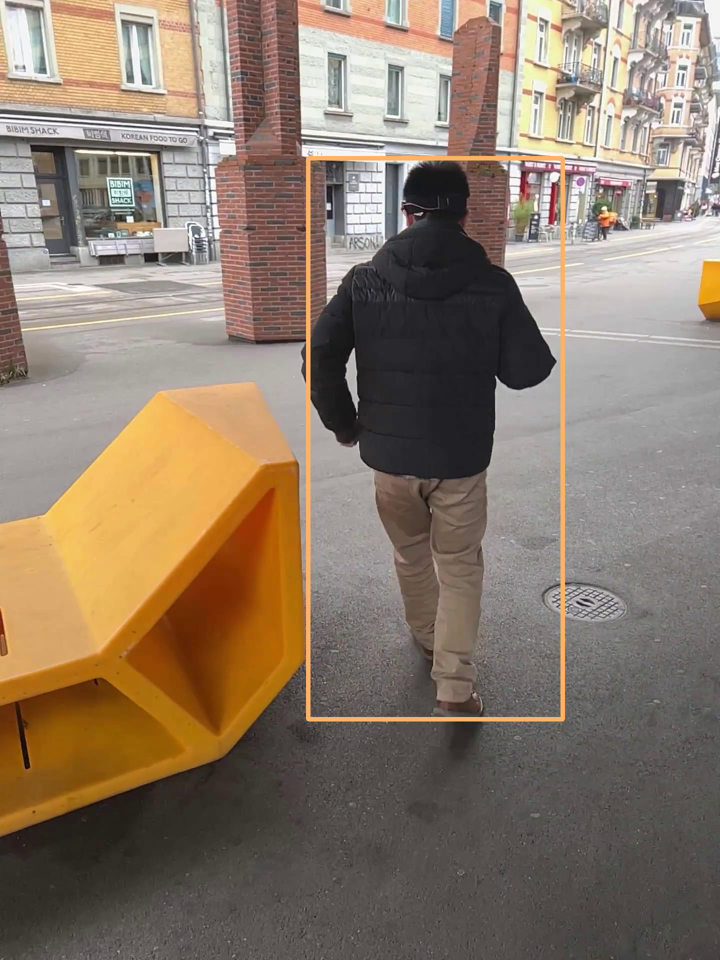

In [8]:
i = 100
img = iio.imread(video_path, index=i)  # (L, H, W, 3) RGB
video_overlay = draw_bbx_xyxy_on_image_batch(bbx_xyxy[i:i+1], [img], thickness=8)
Image.fromarray(video_overlay[0]).resize((width // 2, height // 2))

In [9]:
vitpose = vitpose_extractor.extract(str(video_path), bbx_xys) # (L, 17, 3)
# vitpose[...,2] = torch.clamp((vitpose[...,  2] - 0.5) * 2, 0.0, 1.0)
vitpose[...,2][vitpose[...,2] < 0.8] = 0.0
vit_features_hmr = extractor_hmr.extract_video_features(str(video_path), bbx_xys) # (L, 1024)
# vit_features_dino = extractor_dino.extract_video_features(str(video_path), bbx_xys) # (L, 1024)

simple_vo = SimpleVO(video_path, scale=0.5, step=8, method="sift", f_mm=None)
vo_results = simple_vo.compute() # (L, 4, 4)
R_w2c = torch.from_numpy(vo_results[:, :3, :3]) # (L, 3, 3)
K_fullimg = estimate_K(width, height).repeat(length, 1, 1) # (L, 3, 3)

ViTPose: 100%|██████████| 8/8 [00:05<00:00,  1.49it/s]


[SimpleVO] Choosen frames shape: (16, 960, 720, 3)
TwoViewGeometryOptions:
    min_num_inliers = 10
    min_E_F_inlier_ratio = 0.8
    max_H_inlier_ratio = 0.9
    watermark_min_inlier_ratio = 0.7
    watermark_border_size = 0.1
    detect_watermark = True
    multiple_ignore_watermark = True
    watermark_detection_max_error = 4.0
    filter_stationary_matches = False
    stationary_matches_max_error = 4.0
    force_H_use = False
    compute_relative_pose = True
    multiple_models = False
    ransac: RANSACOptions:
        max_error = 4.0
        min_inlier_ratio = 0.25
        confidence = 0.999
        dyn_num_trials_multiplier = 3.0
        min_num_trials = 100
        max_num_trials = 10000
        random_seed = -1


100%|██████████| 15/15 [00:10<00:00,  1.39it/s]


### 3. Model Inference

In [10]:
with torch.no_grad():
    data = {
        "length": torch.tensor(length),
        "bbx_xys": bbx_xys,
        "kp2d": vitpose,
        "K_fullimg": K_fullimg,
        "cam_angvel": compute_cam_angvel(R_w2c),
        "f_imgseq": vit_features_hmr,
    }
    pred = model.predict(data, static_cam=False)
    
final_results = {
    "input_video" : str(video_path.absolute()),
    'model_dir': str(cfg.ckpt_path),
    "dimensions" : (length, width, height),
    "bbx_xyxy": bbx_xyxy, "bbx_xys": bbx_xys,
    "vitpose": vitpose,
    'vit_features': vit_features_hmr,
    'R_w2c': R_w2c,
    'K_fullimg': K_fullimg,
    'smpl_params_global' : pred["smpl_params_global"],
    'smpl_params_incam' : pred["smpl_params_incam"],
}

### 4. Render InCamera View

In [11]:
# smpl
length, width, height = final_results['dimensions']
r_width, r_height = width, height # 
# final_results = torch.load(output_root / f"{video_path.stem}.pt")
# length, width, height = final_results['dimensions']
# plot_angle_changes(final_results["smpl_params_global"]['global_orient'])

renderer_c = Renderer(r_width, r_height, device="cuda", faces=faces_smpl, K=estimate_K(r_width, r_height))

smplx_c = smplx(**final_results["smpl_params_incam"])
pred_c_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smplx_c.vertices])
pred_c_joints, pred_c_valid = renderer_c.project_points_to_full_image(smplx_c.joints)

smplx_gb = smplx(**final_results["smpl_params_global"])
pred_gb_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smplx_gb.vertices])
pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(pred_gb_verts, J_regressor)

global_R, global_T, global_lights = get_global_cameras_static(
    pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
)
_, _, K = create_camera_sensor(r_width, r_height, 24)
renderer_g = Renderer(r_width, r_height, device="cuda", faces=faces_smpl, K=K)

# -- render mesh -- #
scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
renderer_g.set_ground(scale * 1.5, cx, cz)
color = torch.ones(3).float().cuda() * 0.8

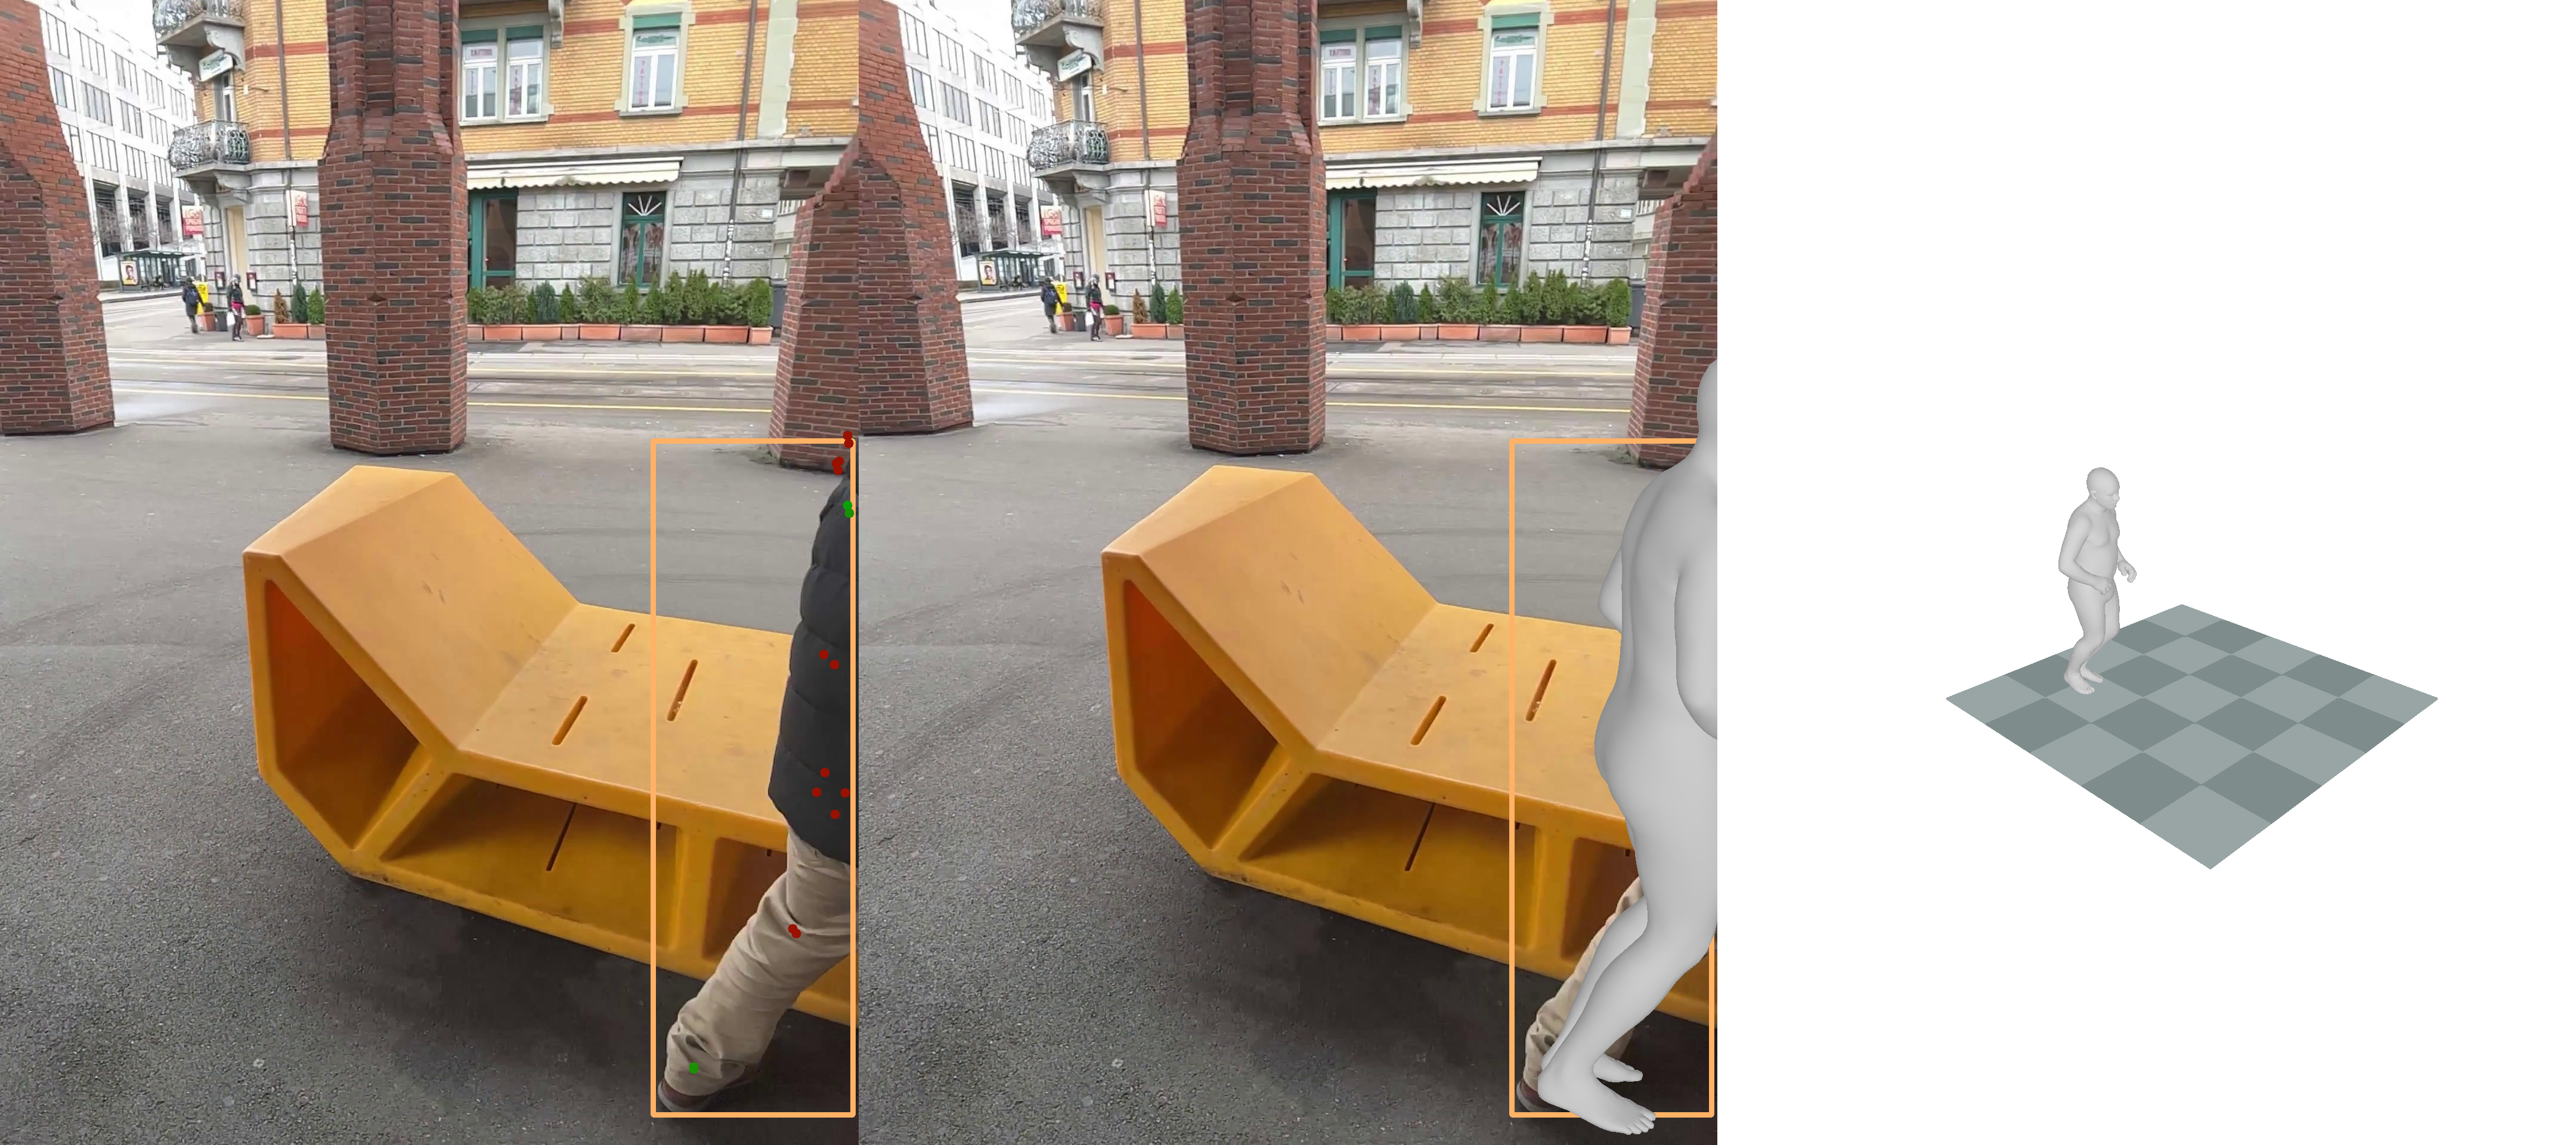

In [12]:
i = 60

img_raw = cv2.resize(iio.imread(final_results['input_video'], index=i), (width, height))
img_raw = draw_bbx_xyxy_on_image_batch(final_results['bbx_xyxy'][i:i+1], [img_raw], thickness=8)[0]
img_raw = draw_kpts_with_conf_batch(
    [img_raw[..., ::-1]], final_results['vitpose'][i:i+1, ..., :2], 
                            final_results['vitpose'][i:i+1, ...,  2], thickness=8)[0][...,::-1]
img_raw = cv2.resize(img_raw, (r_width, r_height))

img_cam = renderer_c.render_mesh(pred_c_verts[i].cuda(), img_raw, colors=[0.8, 0.8, 0.8])
# img_cam = draw_kpts_with_conf_batch([img_cam], pred_c_joints[i:i+1][:,:-98], pred_c_valid[i:i+1][:,:-98], thickness=4)[0]

cameras = renderer_g.create_camera(global_R[i], global_T[i])
img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)

Image.fromarray(np.concatenate([img_raw, img_cam, img_gb], axis=1))

In [13]:
# writer = get_writer(output_root / f'og-{video_path.stem}.mp4', fps=10, crf=23)
writer = get_writer(f'tmp.mp4', fps=30, crf=23)
for i in tqdm(range(length), desc=f"Rendering Global"):
    img_raw = cv2.resize(iio.imread(final_results['input_video'], index=i), (r_width, r_height))
    img_raw = draw_bbx_xyxy_on_image_batch(final_results['bbx_xyxy'][i:i+1], [img_raw], thickness=8)[0]
    # img_raw = draw_kpts_with_conf_batch([img_raw], pred_c_joints[i:i+1], pred_c_valid[i:i+1], thickness=4)[0]

    img_cam = renderer_c.render_mesh(pred_c_verts[i].cuda(), img_raw, colors=[0.8, 0.8, 0.8])
    # img_cam = draw_kpts_with_conf_batch([img_cam], pred_c_joints[i:i+1], pred_c_valid[i:i+1], thickness=4)[0]

    cameras = renderer_g.create_camera(global_R[i], global_T[i])
    img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)
    img = np.concatenate([img_raw, img_cam, img_gb], axis=1)
    writer.write_frame(img)
writer.close()

Rendering Global: 100%|██████████| 120/120 [03:22<00:00,  1.69s/it]


In [ ]:
# from hmr4d.utils.vis.renderer import overlay_image_onto_background

# i = 250

# cameras = renderer_g.create_camera(global_R[i], global_T[i])
# img_gb = renderer_g.render_with_ground(pred_gb_verts[[i]], color[None], cameras, global_lights)

# frust_verts_cam, frust_faces = frustum_vertices_in_camera(K.cuda(), W=r_width, H=r_height, z_near=1.0)
# frust_verts_wld = camera_to_world_points(frust_verts_cam, R_cw=R_cw_all[i], t_cw=t_cw_all[i,...,0])

# vertices=frust_verts_wld.to('cuda')
# faces=frust_faces.unsqueeze(0).to('cuda')
# background=img_gb
# colors=[0.0, 0.8, 0.8]
# update_bbox=False
# flip=False

# if update_bbox:
#     renderer_g.update_bbox(vertices[::50], scale=1.2)
# vertices = vertices.unsqueeze(0)

# if isinstance(colors, torch.Tensor):
#     # per-vertex color
#     verts_features = colors.to(device=vertices.device, dtype=vertices.dtype)
#     colors = [0.8, 0.8, 0.8]
# else:
#     if colors[0] > 1:
#         colors = [c / 255.0 for c in colors]
#     verts_features = torch.tensor(colors).reshape(1, 1, 3).to(device=vertices.device, dtype=vertices.dtype)
#     verts_features = verts_features.repeat(1, vertices.shape[1], 1)
# textures = TexturesVertex(verts_features=verts_features)

# if faces is None:
#     faces = renderer_g.faces
# mesh = Meshes(verts=vertices, faces=faces, textures=textures)

# materials = Materials(device=renderer_g.device, specular_color=(colors,), shininess=0)

# results = renderer_g.renderer(mesh, materials=materials, cameras=renderer_g.cameras, lights=renderer_g.lights)
# if flip:
#     results = torch.flip(results, [1, 2])
# image = results[0, ..., :3] * 255
# mask = results[0, ..., -1] > 1e-3

# if background is None:
#     background = np.ones((renderer_g.height, renderer_g.width, 3)).astype(np.uint8) * 255
    
# if update_bbox:
#     bbox = renderer_g.bboxes
# else:
#     bbox = torch.tensor([[0, 0, renderer_g.width, renderer_g.height]]).float().to(renderer_g.device)

# image = overlay_image_onto_background(image, mask, bbox, background.copy())
# renderer_g.reset_bbox()

# Image.fromarray(image)

In [ ]:
# from einops import einsum
# from hmr4d.utils.geo_transform import kabsch_algorithm_batch

# tmp_pred_c_joints = einsum(J_regressor, pred_c_verts, "j v, l v i -> l j i")

# R_cw_all = []
# t_cw_all = []
# for Xc, Xw in zip(tmp_pred_c_joints, pred_gb_joints):
#     R, t = kabsch_algorithm_batch(Xw, Xc)
#     R_cw_all.append(R)
#     t_cw_all.append(t)
# R_cw_all = torch.stack(R_cw_all, dim=0)
# t_cw_all = torch.stack(t_cw_all, dim=0)

# # from pytorch3d.transforms import axis_angle_to_matrix

# # R_cb = axis_angle_to_matrix(final_results["smpl_params_incam"]['global_orient'])
# # t_cb = final_results["smpl_params_incam"]['transl']

# # R_wb = axis_angle_to_matrix(final_results["smpl_params_global"]['global_orient'])
# # t_wb = final_results["smpl_params_global"]['transl']

# # R_cw_all = R_cb @ R_wb.transpose(-1, -2)                # (T,3,3)
# # t_cw_all = t_cb - (R_cw_all @ t_wb.unsqueeze(-1)).squeeze(-1)  # (T,3)

# # R_wc_all = R_cw_all.transpose(-1, -2)
# # t_wc_all = t_wb - (R_wc_all @ t_cb.unsqueeze(-1)).squeeze(-1)

# frust_verts_cam, frust_faces = frustum_vertices_in_camera(K.cuda(), W=r_width, H=r_height, offset_z=2.0)

In [ ]:
# # frust_verts_wld = camera_to_world_points(frust_verts_cam, R_cw=R_cw_all[i], t_cw=t_cw_all[i,...,0])
# frust_verts_wld = (R_cw_all[i].T @ (frust_verts_cam - t_cw_all[i,...][None]).T).T
# img_gb = renderer_g.render_mesh(
#     frust_verts_wld.to('cuda'), 
#     faces=frust_faces.unsqueeze(0).to('cuda'), 
#     background=img_gb, 
#     colors=[0.0, 0.8, 0.8], update_bbox=False, flip=True
# )